In [91]:
from espn_api.football import League
import numpy as np
import pandas as pd
import pulp
import matplotlib.pyplot as plt
import requests
import creds

LEAGUE_ID = 1821237400
YEAR = 2025
ESPN_S2 = "AEBCl45LNO4%2FYiR8%2BVvz3OZsi0Quj3hBiHdLNLuQ8rBll4JymvtmMMmWsatNxXJb2LF%2BVNdPHzrsOpm9kHrqyCU%2B2Cui%2BwagofEMzlcOCK32xm1hoMAXyQc%2FmCLFaqIOY5C%2BwNFxFvtheAd0scKPCfZpEYG102%2F6AgMJxei7v6JTUf5crqcDD9GV889uUoIPPKo7t4nc%2F2W7Ke7k3804q%2B8k3yq4eQq1xYFYp6lr01KWEh7dO3DDXlSWpKJJ8JQpFx6ia0UlIXT39O2lRlxokODiz8liFax%2FNcnvm3uTmaGGkg%3D%3D"
SWID = "{70B0D541-7666-4B31-8869-4361D56693B2}"
API_KEY = creds.api_key

league = League(league_id=LEAGUE_ID, year=YEAR, espn_s2=ESPN_S2, swid=SWID)
print(f"Connected to: {league.settings.name}")

Connected to: My 2026 League


In [92]:
print(league.teams[11])

Team(🤓)


In [93]:
team_id = 3
week = 12
my_team = league.teams[2]

matchups = league.box_scores(week)
my_matchup = next(m for m in matchups if m.home_team.team_id == team_id or m.away_team.team_id == team_id)
my_lineup = my_matchup.home_lineup if my_matchup.home_team.team_id == team_id else my_matchup.away_lineup

TEAM_MAP = {
    'ARI': 'Arizona Cardinals', 'ATL': 'Atlanta Falcons', 'BAL': 'Baltimore Ravens',
    'BUF': 'Buffalo Bills', 'CAR': 'Carolina Panthers', 'CHI': 'Chicago Bears',
    'CIN': 'Cincinnati Bengals', 'CLE': 'Cleveland Browns', 'DAL': 'Dallas Cowboys',
    'DEN': 'Denver Broncos', 'DET': 'Detroit Lions', 'GB': 'Green Bay Packers',
    'HOU': 'Houston Texans', 'IND': 'Indianapolis Colts', 'JAX': 'Jacksonville Jaguars',
    'KC': 'Kansas City Chiefs', 'LV': 'Las Vegas Raiders', 'LAC': 'Los Angeles Chargers',
    'LAR': 'Los Angeles Rams', 'MIA': 'Miami Dolphins', 'MIN': 'Minnesota Vikings',
    'NE': 'New England Patriots', 'NO': 'New Orleans Saints', 'NYG': 'New York Giants',
    'NYJ': 'New York Jets', 'PHI': 'Philadelphia Eagles', 'PIT': 'Pittsburgh Steelers',
    'SF': 'San Francisco 49ers', 'SEA': 'Seattle Seahawks', 'TB': 'Tampa Bay Buccaneers',
    'TEN': 'Tennessee Titans', 'WSH': 'Washington Commanders'
}

order = ['QB', 'RB', "WR", 'TE', 'RB/WR/TE', 'D/ST', 'K', 'BE']


lineup_data = []
for player in my_lineup:
    # Use try/except or a default for players without season stats yet
    try:
        avg_pts = league.player_info(player.name).avg_points
    except:
        avg_pts = 0
    
    espn_abbr = player.proTeam
    full_name = TEAM_MAP.get(espn_abbr, "Unknown")
        
    lineup_data.append({
        "Name": player.name,
        "Team": full_name,
        "Position": player.position,
        "Slot": player.slot_position,
        "Projected": player.projected_points,
        "Actual": player.points,
        "Opp_Rank": player.pro_pos_rank,
        "Avg_Points": avg_pts
    })
df = pd.DataFrame(lineup_data)
display(df) # Pretty-print the table in Notebook

,Name,Team,Position,Slot,Projected,Actual,Opp_Rank,Avg_Points
0,Puka Nacua,Los Angeles Rams,WR,WR,20.71,16.70,20,23.81
1,Derrick Henry,Baltimore Ravens,RB,RB,17.12,22.80,30,14.18
2,Josh Allen,Buffalo Bills,QB,QB,19.13,8.12,1,23.90
3,Omarion Hampton,Los Angeles Chargers,RB,IR,0.00,0.00,0,14.17
4,Keenan Allen,Los Angeles Chargers,WR,BE,0.00,0.00,0,11.43
5,Jared Goff,Detroit Lions,QB,BE,17.75,17.16,31,18.09
6,Brock Bowers,Las Vegas Raiders,TE,TE,15.15,11.50,11,14.72
7,Jaylen Warren,Pittsburgh Steelers,RB,RB,14.38,12.80,15,12.82
8,Chris Boswell,Pittsburgh Steelers,K,K,8.32,4.00,6,8.57
9,Cade Otton,Tampa Bay Buccaneers,TE,BE,9.49,6.10,19,6.85


In [94]:
# def get_vegas_totals(api_key):
#     url = f"https://api.the-odds-api.com/v4/sports/americanfootball_nfl/odds/"
#     params = {
#         'apiKey': api_key,
#         'regions': 'us',
#         'markets': 'totals',
#         'oddsFormat': 'american',
#     }
#     response = requests.get(url, params=params).json()
    
#     vegas_map = {}
#     for game in response:
#         home_team = game['home_team']
#         away_team = game['away_team']
        
#         # Pull the 'Total' (Over/Under) from the first bookmaker listed
#         try:
#             total = game['bookmakers'][0]['markets'][0]['outcomes'][0]['point']
#             vegas_map[home_team] = total
#             vegas_map[away_team] = total
#         except (IndexError, KeyError):
#             continue
            
#     return vegas_map

# totals_dict = get_vegas_totals(API_KEY)

In [95]:
# 1. POSITIONAL SCALES (How much a matchup actually matters)
POSITIONAL_SCALES = {
    'QB': [0.85, 1.10],   # QBs are more resilient to bad matchups
    'RB': [0.75, 1.25],   # RBs are very matchup-dependent
    'WR': [0.80, 1.20],   
    'TE': [0.70, 1.15],   
    'DEF': [0.60, 1.40],  # D/ST depends heavily on the opponent
    'K': [0.95, 1.05]     
}

# 2. VEGAS MULTIPLIER (Boost for shootouts, Penalty for slugfests)
def get_vegas_multiplier(team_name, totals_dict):
    total = totals_dict.get(team_name, 44.0) # Default to 44 if not found
    if total >= 50: return 1.10   # High scoring game boost
    if total <= 40: return 0.90   # Low scoring "slugfest" penalty
    return 1.0                    # Neutral

# 3. COMBINED ADJUSTMENT FUNCTION
def adjust_projection(row, totals_dict):
    # Matchup Adjustment
    pos = row['Position']
    low, high = POSITIONAL_SCALES.get(pos, [0.9, 1.1])
    matchup_scale = np.interp(row['Opp_Rank'], [1, 32], [low, high])
    
    # Vegas Adjustment
    # Note: Ensure player.pro_team matches the team name in totals_dict
    vegas_scale = get_vegas_multiplier(row['Team'], totals_dict)
    
    # Weighted Baseline
    baseline = (row['Projected'] * 0.35) + (row['Avg_Points'] * 0.65)
    
    return baseline * matchup_scale * vegas_scale


In [96]:
def solve_lineup(data_df, score_col):
    prob = pulp.LpProblem("BestLineup", pulp.LpMaximize)
    
    # Create binary variables for each player
    player_vars = pulp.LpVariable.dicts("Players", data_df.index, cat=pulp.LpBinary)
    
    # Objective: Maximize the chosen score column
    prob += pulp.lpSum([data_df.loc[i, score_col] * player_vars[i] for i in data_df.index])
    
    # Constraints (Standard Roster: 1 QB, 2 RB, 2 WR, 1 TE, 1 FLEX, 1 K, 1 D/ST)
    prob += pulp.lpSum([player_vars[i] for i in data_df.index if data_df.loc[i, 'Position'] == 'QB']) == 1
    prob += pulp.lpSum([player_vars[i] for i in data_df.index if data_df.loc[i, 'Position'] == 'RB']) >= 2
    prob += pulp.lpSum([player_vars[i] for i in data_df.index if data_df.loc[i, 'Position'] == 'WR']) >= 2
    prob += pulp.lpSum([player_vars[i] for i in data_df.index if data_df.loc[i, 'Position'] == 'TE']) >= 1
    prob += pulp.lpSum([player_vars[i] for i in data_df.index if data_df.loc[i, 'Position'] in ['RB', 'WR', 'TE']]) == 6 # 2RB + 2WR + 1TE + 1FLEX
    prob += pulp.lpSum([player_vars[i] for i in data_df.index if data_df.loc[i, 'Position'] == 'K']) == 1
    prob += pulp.lpSum([player_vars[i] for i in data_df.index if data_df.loc[i, 'Position'] in ['D/ST', 'DEF']]) == 1
    
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    
    chosen_indices = [i for i in data_df.index if player_vars[i].varValue == 1]
    return data_df.loc[chosen_indices]

# Apply adjustments
df['Adjusted_Projected'] = df.apply(lambda row: adjust_projection(row, totals_dict), axis=1)
df['Slot'] = pd.Categorical(df['Slot'], categories=order, ordered=True)
df['Position'] = pd.Categorical(df['Position'], categories=order, ordered=True)
df['Game_Total'] = df['Team'].map(totals_dict)

# Get Lineups
best_adj = solve_lineup(df, 'Adjusted_Projected')
best_espn = solve_lineup(df, 'Projected')
best_actual = solve_lineup(df, 'Actual')

print(f"My Optimized Total: {best_adj['Adjusted_Projected'].sum():.2f}")
print(f"My Actual Total: {best_adj['Actual'].sum():.2f}")
print(f"ESPN Optimized Total: {best_espn['Projected'].sum():.2f}")
print(f"ESPN Actual Total: {best_espn['Actual'].sum():.2f}")
print(f"Best Possible: {best_actual['Actual'].sum():.2f}")

My Optimized Total: 121.68
My Actual Total: 121.36
ESPN Optimized Total: 128.94
ESPN Actual Total: 112.32
Best Possible: 127.66


In [97]:
def solve_lineup_pulp(df, points_col="Adjusted_Projected"):
    # 1. Initialize the Problem
    prob = pulp.LpProblem("Fantasy_Optimizer", pulp.LpMaximize)
    
    # 2. Decision Variables (1 if player is started, 0 if on bench)
    player_vars = pulp.LpVariable.dicts("player", df.index, cat='Binary')
    
    # 3. Objective Function: Maximize total points
    prob += pulp.lpSum([df.loc[i, points_col] * player_vars[i] for i in df.index])
    
    # 4. Constraints (Standard Roster: 1 QB, 2 RB, 2 WR, 1 TE, 1 K, 1 DEF, 1 FLEX)
    # Total players in starting lineup = 9
    prob += pulp.lpSum([player_vars[i] for i in df.index]) == 9
    
    # Position Minimums
    prob += pulp.lpSum([player_vars[i] for i in df.index if df.loc[i, 'Position'] == 'QB']) == 1
    prob += pulp.lpSum([player_vars[i] for i in df.index if df.loc[i, 'Position'] == 'RB']) >= 2
    prob += pulp.lpSum([player_vars[i] for i in df.index if df.loc[i, 'Position'] == 'WR']) >= 2
    prob += pulp.lpSum([player_vars[i] for i in df.index if df.loc[i, 'Position'] == 'TE']) >= 1
    prob += pulp.lpSum([player_vars[i] for i in df.index if df.loc[i, 'Position'] == 'K']) == 1
    prob += pulp.lpSum([player_vars[i] for i in df.index if df.loc[i, 'Position'] in ['D/ST', 'DEF']]) == 1
    
    # FLEX Constraint: Exactly 6 spots for RB/WR/TE combined (2+2+1 + 1 FLEX)
    prob += pulp.lpSum([player_vars[i] for i in df.index if df.loc[i, 'Position'] in ['RB', 'WR', 'TE']]) == 6

    # 5. Solve
    prob.solve(pulp.PULP_CBC_CMD(msg=0))
    
    # 6. Extract Results
    df['is_starter'] = [pulp.value(player_vars[i]) for i in df.index]
    
    optimized_lineup = df[df['is_starter'] == 1].copy()
    bench = df[df['is_starter'] == 0].copy()
    
    return optimized_lineup, bench

In [99]:
# Assuming 'df' is your processed dataframe from the previous steps
myOptimizedLineup, myBench = solve_lineup_pulp(df, "Adjusted_Projected")

print(f"Total Projected Points: {myOptimizedLineup['Adjusted_Projected'].sum():.2f}")
display(myOptimizedLineup[['Name', 'Position', 'Adjusted_Projected', 'Actual', 'Projected']])
best_espn, espnBench = solve_lineup_pulp(df, 'Projected')
best_actual, actualBench = solve_lineup_pulp(df, 'Actual')
print(f"My Optimized Total: {myOptimizedLineup['Adjusted_Projected'].sum():.2f}")
print(f"My Actual Total: {myOptimizedLineup['Actual'].sum():.2f}")
print(f"ESPN Optimized Total: {best_espn['Projected'].sum():.2f}")
print(f"ESPN Actual Total: {best_espn['Actual'].sum():.2f}")
print(f"Best Possible: {best_actual['Actual'].sum():.2f}")

Total Projected Points: 121.68


,Name,Position,Adjusted_Projected,Actual,Projected
0,Puka Nacua,WR,23.751290,16.70,20.71
1,Derrick Henry,RB,18.520637,22.80,17.12
5,Jared Goff,QB,19.623173,17.16,17.75
6,Brock Bowers,TE,12.567971,11.50,15.15
7,Jaylen Warren,RB,11.738366,12.80,14.38
8,Chris Boswell,K,7.375671,4.00,8.32
10,Romeo Doubs,WR,8.541200,4.30,12.36
13,Browns D/ST,D/ST,7.731215,17.00,7.72
16,Jauan Jennings,WR,11.829017,15.10,14.05


My Optimized Total: 121.68
My Actual Total: 121.36
ESPN Optimized Total: 128.94
ESPN Actual Total: 112.32
Best Possible: 127.66


In [100]:
display(best_actual.sort_values(by="Position"))

,Name,Team,Position,Slot,Projected,Actual,Opp_Rank,Avg_Points,Adjusted_Projected,Game_Total,is_starter
5,Jared Goff,Detroit Lions,QB,BE,17.75,17.16,31,18.09,19.623173,48.5,1.0
1,Derrick Henry,Baltimore Ravens,RB,RB,17.12,22.80,30,14.18,18.520637,46.5,1.0
7,Jaylen Warren,Pittsburgh Steelers,RB,RB,14.38,12.80,15,12.82,11.738366,35.5,1.0
0,Puka Nacua,Los Angeles Rams,WR,WR,20.71,16.70,20,23.81,23.751290,48.5,1.0
14,Andrei Iosivas,Cincinnati Bengals,WR,BE,8.71,10.60,16,5.41,7.174910,51.5,1.0
16,Jauan Jennings,San Francisco 49ers,WR,RB/WR/TE,14.05,15.10,7,11.29,11.829017,50.5,1.0
6,Brock Bowers,Las Vegas Raiders,TE,TE,15.15,11.50,11,14.72,12.567971,42.5,1.0
13,Browns D/ST,Cleveland Browns,D/ST,D/ST,7.72,17.00,30,8.00,7.731215,35.5,1.0
8,Chris Boswell,Pittsburgh Steelers,K,K,8.32,4.00,6,8.57,7.375671,35.5,1.0


In [101]:


display(df.sort_values(by="Slot"))

actual_start = best_adj['Actual'].sum()
potential_max = best_actual['Actual'].sum() # Assuming 9 roster spots

print(f"--- Weekly Performance ---")
print(f"Starting Lineup Points: {actual_start:.2f}")
print(f"Potential Max: {potential_max:.2f}")
print(f"Manager Efficiency: {(actual_start / potential_max) * 100:.1f}%")

,Name,Team,Position,Slot,Projected,Actual,Opp_Rank,Avg_Points,Adjusted_Projected,Game_Total,is_starter
2,Josh Allen,Buffalo Bills,QB,QB,19.13,8.12,1,23.90,18.895925,45.5,0.0
1,Derrick Henry,Baltimore Ravens,RB,RB,17.12,22.80,30,14.18,18.520637,46.5,1.0
7,Jaylen Warren,Pittsburgh Steelers,RB,RB,14.38,12.80,15,12.82,11.738366,35.5,1.0
0,Puka Nacua,Los Angeles Rams,WR,WR,20.71,16.70,20,23.81,23.751290,48.5,1.0
10,Romeo Doubs,Green Bay Packers,WR,WR,12.36,4.30,1,9.77,8.541200,46.5,0.0
6,Brock Bowers,Las Vegas Raiders,TE,TE,15.15,11.50,11,14.72,12.567971,42.5,1.0
16,Jauan Jennings,San Francisco 49ers,WR,RB/WR/TE,14.05,15.10,7,11.29,11.829017,50.5,1.0
13,Browns D/ST,Cleveland Browns,D/ST,D/ST,7.72,17.00,30,8.00,7.731215,35.5,1.0
8,Chris Boswell,Pittsburgh Steelers,K,K,8.32,4.00,6,8.57,7.375671,35.5,1.0
4,Keenan Allen,Los Angeles Chargers,WR,BE,0.00,0.00,0,11.43,5.349240,39.5,0.0


--- Weekly Performance ---
Starting Lineup Points: 121.36
Potential Max: 127.66
Manager Efficiency: 95.1%


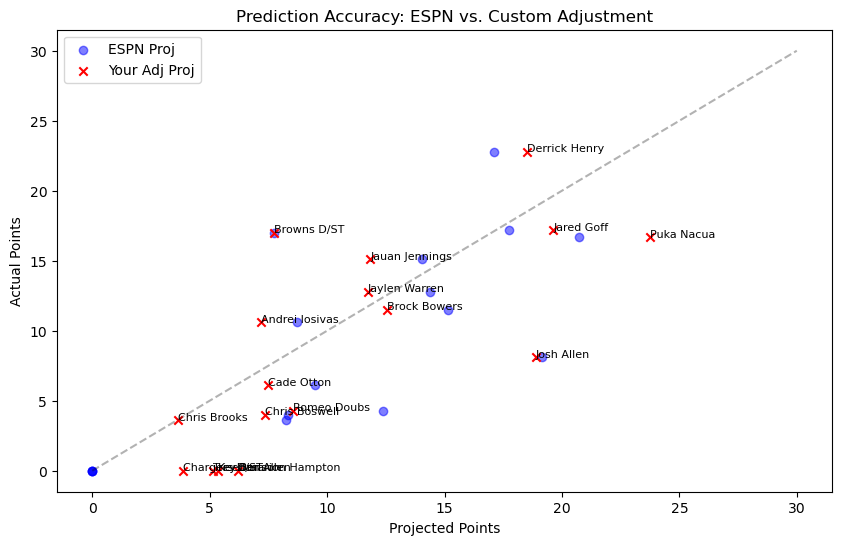

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Projected'], df['Actual'], color='blue', label='ESPN Proj', alpha=0.5)
plt.scatter(df['Adjusted_Projected'], df['Actual'], color='red', label='Your Adj Proj', marker='x')

for i, txt in enumerate(df['Name']):
    plt.annotate(txt, (df['Adjusted_Projected'].iat[i], df['Actual'].iat[i]), size=8)

plt.plot([0, 30], [0, 30], 'k--', alpha=0.3) # Perfect prediction line
plt.xlabel('Projected Points')
plt.ylabel('Actual Points')
plt.title('Prediction Accuracy: ESPN vs. Custom Adjustment')
plt.legend()
plt.show()